In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [4]:
x_train=x_train/255
x_test=x_test/255

In [5]:
x_train=x_train.reshape(60000,784)
x_test=x_test.reshape(10000,784)

x_train=x_train.T
x_test=x_test.T

In [6]:
def init_params():
    W1 = np.random.rand(128, 784) - 0.5 
    b1 = np.random.rand(128, 1) - 0.5  
    W2 = np.random.rand(64, 128) - 0.5
    b2 = np.random.rand(64, 1) - 0.5
    W3 = np.random.rand(10, 64) - 0.5
    b3 = np.random.rand(10, 1) - 0.5
    
    return W1, b1, W2, b2, W3, b3

In [7]:
def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

In [8]:
def forward_prop(W1, b1, W2, b2, W3, b3, X):

    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)

    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)

    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [9]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

In [ ]:
def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

Y_hot [[0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]]


In [11]:
def backward_prop(Z1, A1, Z2, A2, Z3, A3, W1, W2, W3, X, Y):
    m = X.shape[1]
    
    one_hot_Y = one_hot(Y)

    dZ3 = A3 - one_hot_Y
    dW3 = (1 / m) * dZ3.dot(A2.T)
    db3 = (1 / m) * np.sum(dZ3, axis=1, keepdims=True)
    
    dZ2 = W3.T.dot(dZ3) * ReLU_deriv(Z2)
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2, dW3, db3


In [12]:
def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    W3 = W3 - alpha * dW3
    b3 = b3 - alpha * db3

    return W1, b1, W2, b2, W3, b3


In [13]:
def get_predictions(A3):
    return np.argmax(A3, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [14]:
loss_history=[]

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2, W3, b3 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2, Z3, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)
        dW1, db1, dW2, db2, dW3, db3 = backward_prop(Z1, A1, Z2, A2, Z3, A3, W1, W2, W3, X, Y)

        W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha)
        one_hot_Y = one_hot(Y)
        loss = binary_cross_entropy(one_hot_Y, A3)
        loss_history.append(loss)
        if i % 10 == 0:
            print("Iteration:", i)
            predictions = get_predictions(A3)
            print("Accuracy:", get_accuracy(predictions, Y))

    return W1, b1, W2, b2, W3, b3,loss_history

In [15]:
W1, b1, W2, b2,W3,b3,loss_history = gradient_descent(x_train, y_train, 0.10, 100)

Iteration: 0
[2 7 0 ... 7 0 0] [5 0 4 ... 5 6 8]
Accuracy: 0.09618333333333333
Iteration: 10
[8 0 4 ... 8 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.5072166666666666
Iteration: 20
[8 0 4 ... 8 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.6260166666666667
Iteration: 30
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.6869166666666666
Iteration: 40
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.7251333333333333
Iteration: 50
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.7522
Iteration: 60
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.7725833333333333
Iteration: 70
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.7889333333333334
Iteration: 80
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.8015666666666666
Iteration: 90
[8 0 4 ... 5 0 7] [5 0 4 ... 5 6 8]
Accuracy: 0.81235


In [16]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)
    predictions = get_predictions(A3)
    return predictions

dev_predictions = make_predictions(x_test, W1, b1, W2, b2,W3,b3)
get_accuracy(dev_predictions, y_test)

[7 2 1 ... 4 5 6] [7 2 1 ... 4 5 6]


0.829

1

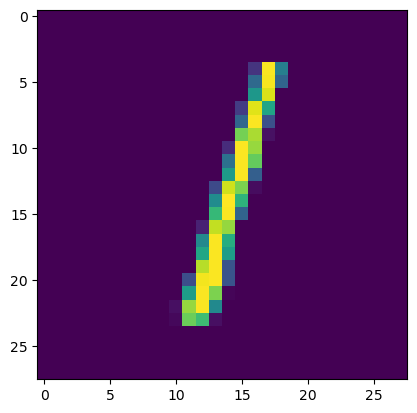

In [17]:
import matplotlib.pyplot as plt
x_new=x_test.T
x_new=x_new.reshape(10000,28,28)
plt.imshow(x_new[2])
dev_predictions[2]

In [18]:
from sklearn.metrics import confusion_matrix

matrix=confusion_matrix(dev_predictions,y_test)
print(matrix)

[[ 888    0   18    4    6   17   34    4    7   16]
 [   0 1077   36    5    3   10    4    7   13    8]
 [  11   10  809   35   12    5   21   28   27    8]
 [  13    5   38  813    4   68    1   15   65   12]
 [   2    1   23    1  825   19   18   13   20   82]
 [  26    3    9   61   14  636   16    3   68   18]
 [  25    6   35    4   18   31  852    0   13    1]
 [   5    5   16   19   10   16    1  880   13   54]
 [   5   28   41   57   10   68    8   21  721   21]
 [   5    0    7   11   80   22    3   57   27  789]]
